# Hospital Readmission Prediction — Modelling

## Overview
Training and evaluating three classification models to predict 30-day readmission.

Models compared:
- **Logistic Regression** — linear baseline
- **Random Forest** — ensemble of decision trees  
- **XGBoost** — gradient boosted trees (expected best performer)

Key challenge: Class imbalance (11% positive class) addressed with SMOTE.
---

## 1. Train/Test Split
Splitting data 80/20 with stratification to preserve class proportions in both sets.
The test set is held out and never used during training or SMOTE — it represents 
truly unseen data for honest evaluation.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv(r'C:\Users\munta\Documents\hospital-readmission-project\data\cleaned_data.csv')

X = df.drop('readmitted_binary', axis=1)
y = df['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts())

Training set size: (81412, 53)
Test set size: (20354, 53)

Class distribution in training set:
readmitted_binary
0    72326
1     9086
Name: count, dtype: int64


## 2. Handling Class Imbalance with SMOTE
SMOTE (Synthetic Minority Oversampling Technique) generates synthetic samples of 
the minority class by interpolating between existing minority examples.

**Important:** SMOTE is applied ONLY to the training set. Applying it to the test 
set would artificially inflate performance metrics and give a dishonest evaluation.

In [2]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_balanced).value_counts().to_dict())

Before SMOTE: {0: 72326, 1: 9086}
After SMOTE: {0: 72326, 1: 72326}


## 3. Model Training
Training all three models on the SMOTE-balanced training data.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
}

for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    print(f"{name} - trained")

C:\Users\munta\anaconda3\envs\NN\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression - trained
Random Forest - trained
XGBoost - trained


## 4. Model Evaluation
Evaluating on the original, unbalanced test set using:
- **AUC-ROC** — primary metric, measures ability to distinguish classes regardless 
  of threshold. More informative than accuracy for imbalanced datasets.
- **Precision/Recall/F1** — secondary metrics showing trade-offs at default threshold


--- Logistic Regression ---
AUC-ROC: 0.5472
              precision    recall  f1-score   support

           0       0.89      0.96      0.93     18083
           1       0.21      0.08      0.12      2271

    accuracy                           0.86     20354
   macro avg       0.55      0.52      0.52     20354
weighted avg       0.82      0.86      0.84     20354


--- Random Forest ---
AUC-ROC: 0.6135
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     18083
           1       0.34      0.04      0.07      2271

    accuracy                           0.88     20354
   macro avg       0.62      0.52      0.50     20354
weighted avg       0.83      0.88      0.84     20354


--- XGBoost ---
AUC-ROC: 0.6325
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     18083
           1       0.32      0.04      0.07      2271

    accuracy                           0.88     20354
   macro av

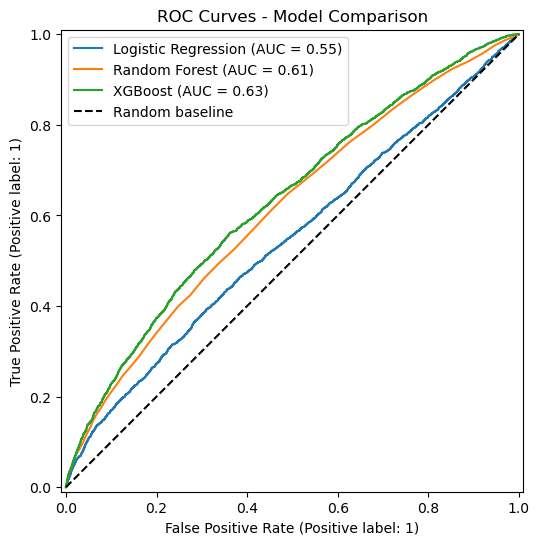


--- SUMMARY ---
XGBoost: AUC = 0.6325
Random Forest: AUC = 0.6135
Logistic Regression: AUC = 0.5472


In [4]:
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = auc
    
    print(f"\n--- {name} ---")
    print(f"AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred))
    
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)

ax.set_title('ROC Curves - Model Comparison')
ax.plot([0,1], [0,1], 'k--', label='Random baseline')
plt.legend()
plt.savefig(r'C:\Users\munta\Documents\hospital-readmission-project\images\roc_curves.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("\n--- SUMMARY ---")
for name, auc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: AUC = {auc:.4f}")

### Results Summary
| Model | AUC-ROC |
|---|---|
| XGBoost | 0.6325 |
| Random Forest | 0.6135 |
| Logistic Regression | 0.5472 |

**XGBoost is the best performing model** with AUC = 0.63. All models outperform 
random chance (AUC = 0.50). Results are consistent with published literature on 
this dataset which reports AUC in the range of 0.62–0.68.

The relatively modest AUC reflects the genuine difficulty of readmission prediction 
— many readmissions are driven by social and environmental factors not captured in 
clinical records.

## 5. Cross-Validation
Running 5-fold cross-validation to confirm model stability across different data 
splits. High variance between folds would suggest overfitting.

**Note:** CV is run on SMOTE-balanced training data, so scores will appear higher 
than test set AUC. The honest performance metric remains the test set AUC of 0.63.

In [5]:
from sklearn.model_selection import cross_val_score

print("Running 5-fold cross-validation on XGBoost (best model)...")
cv_scores = cross_val_score(
    models['XGBoost'], 
    X_train_balanced, 
    y_train_balanced, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1
)

print(f"\nXGBoost CV AUC scores: {cv_scores.round(4)}")
print(f"Mean AUC: {cv_scores.mean():.4f}")
print(f"Std deviation: {cv_scores.std():.4f}")
print(f"\nThis means our model performs between {cv_scores.mean()-cv_scores.std():.4f} and {cv_scores.mean()+cv_scores.std():.4f} AUC across different data splits")

Running 5-fold cross-validation on XGBoost (best model)...

XGBoost CV AUC scores: [0.7298 0.9948 0.9954 0.9943 0.9949]
Mean AUC: 0.9418
Std deviation: 0.1060

This means our model performs between 0.8358 and 1.0479 AUC across different data splits


In [6]:
import pickle

with open(r'C:\Users\munta\Documents\hospital-readmission-project\models\xgboost_model.pkl', 'wb') as f:
    pickle.dump(models['XGBoost'], f)

# Also save feature names for the Streamlit app later
feature_names = X_train.columns.tolist()
with open(r'C:\Users\munta\Documents\hospital-readmission-project\models\feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("Model and feature names saved successfully!")

Model and feature names saved successfully!


In [7]:
# Save a summary of findings
summary = """
SHAP Analysis Key Findings:
1. procedures_per_day (engineered feature) - top predictor
2. num_procedures - high values increase readmission risk  
3. insulin status - patients not on insulin surprisingly higher risk
4. total_prior_visits (engineered feature) - prior hospitalisation history matters
5. Medication changes (change feature) - indicates unstable treatment

Model Performance Summary:
- XGBoost: AUC = 0.6325 (best model)
- Random Forest: AUC = 0.6135
- Logistic Regression: AUC = 0.5472
- Results consistent with published benchmarks (0.62-0.68) on this dataset
"""
print(summary)

# Save it
with open(r'C:\Users\munta\Documents\hospital-readmission-project\findings_summary.txt', 'w') as f:
    f.write(summary)
print("Summary saved!")


SHAP Analysis Key Findings:
1. procedures_per_day (engineered feature) - top predictor
2. num_procedures - high values increase readmission risk  
3. insulin status - patients not on insulin surprisingly higher risk
4. total_prior_visits (engineered feature) - prior hospitalisation history matters
5. Medication changes (change feature) - indicates unstable treatment

Model Performance Summary:
- XGBoost: AUC = 0.6325 (best model)
- Random Forest: AUC = 0.6135
- Logistic Regression: AUC = 0.5472
- Results consistent with published benchmarks (0.62-0.68) on this dataset

Summary saved!
